In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train = pd.read_csv('../data/processed/X_train_fe.csv')
X_test = pd.read_csv('../data/processed/X_test_fe.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    return results

results_list = []

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Re-train baseline here too, so this notebook is self-contained and all 4 models are compared in one place
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
results_list.append(evaluate_model(log_reg, X_test, y_test, 'Logistic Regression'))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
results_list.append(evaluate_model(rf_model, X_test, y_test, 'Random Forest'))

pd.DataFrame(results_list)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
1,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394


In [3]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
results_list.append(evaluate_model(xgb_model, X_test, y_test, 'XGBoost'))

lgbm_model = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)
results_list.append(evaluate_model(lgbm_model, X_test, y_test, 'LightGBM'))

pd.DataFrame(results_list)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
1,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394
2,XGBoost,0.781405,0.607143,0.500000,0.548387,0.807636
3,LightGBM,0.788502,0.620253,0.524064,0.568116,0.823537


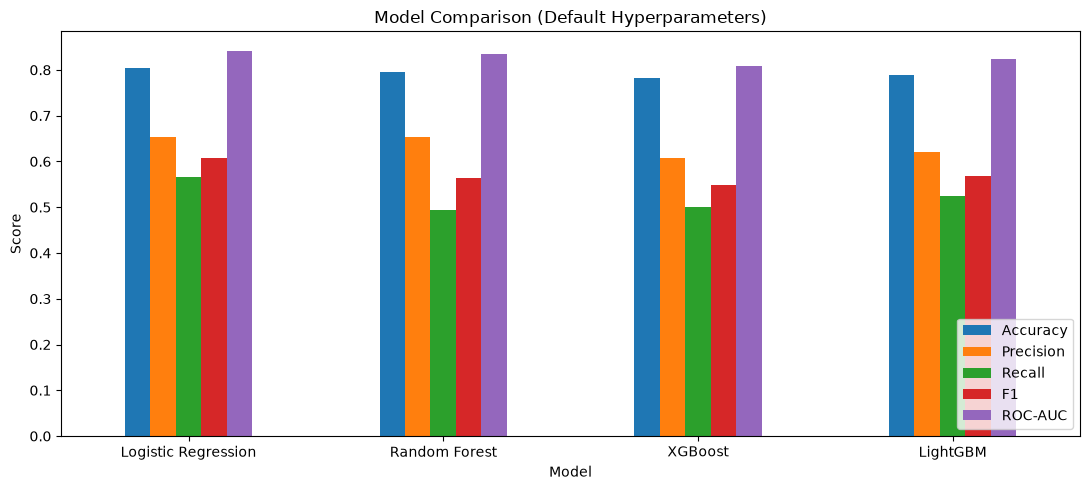

In [4]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results_list).set_index('Model')
results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(11,5))
plt.title('Model Comparison (Default Hyperparameters)')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
rf_balanced = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
results_list.append(evaluate_model(rf_balanced, X_test, y_test, 'Random Forest (balanced)'))

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_balanced = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_balanced.fit(X_train, y_train)
results_list.append(evaluate_model(xgb_balanced, X_test, y_test, 'XGBoost (balanced)'))

lgbm_balanced = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1, class_weight='balanced')
lgbm_balanced.fit(X_train, y_train)
results_list.append(evaluate_model(lgbm_balanced, X_test, y_test, 'LightGBM (balanced)'))

pd.DataFrame(results_list)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
1,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394
2,XGBoost,0.781405,0.607143,0.500000,0.548387,0.807636
3,LightGBM,0.788502,0.620253,0.524064,0.568116,0.823537
4,Random Forest (balanced),0.779276,0.573770,0.655080,0.611735,0.832920
5,XGBoost (balanced),0.770759,0.562654,0.612299,0.586428,0.809078
6,LightGBM (balanced),0.768630,0.550847,0.695187,0.614657,0.829443


In [6]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV F1:", xgb_search.best_score_)

results_list.append(evaluate_model(xgb_search.best_estimator_, X_test, y_test, 'XGBoost (tuned)'))
pd.DataFrame(results_list)

Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV F1: 0.6355166483960621


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
1,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394
2,XGBoost,0.781405,0.607143,0.500000,0.548387,0.807636
3,LightGBM,0.788502,0.620253,0.524064,0.568116,0.823537
4,Random Forest (balanced),0.779276,0.573770,0.655080,0.611735,0.832920
5,XGBoost (balanced),0.770759,0.562654,0.612299,0.586428,0.809078
6,LightGBM (balanced),0.768630,0.550847,0.695187,0.614657,0.829443
7,XGBoost (tuned),0.750887,0.520211,0.791444,0.627784,0.844151


In [7]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

results_list.append(evaluate_model(rf_search.best_estimator_, X_test, y_test, 'Random Forest (tuned)'))
pd.DataFrame(results_list)

Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
Best CV F1: 0.6366691003901399


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
1,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394
2,XGBoost,0.781405,0.607143,0.500000,0.548387,0.807636
3,LightGBM,0.788502,0.620253,0.524064,0.568116,0.823537
4,Random Forest (balanced),0.779276,0.573770,0.655080,0.611735,0.832920
5,XGBoost (balanced),0.770759,0.562654,0.612299,0.586428,0.809078
6,LightGBM (balanced),0.768630,0.550847,0.695187,0.614657,0.829443
7,XGBoost (tuned),0.750887,0.520211,0.791444,0.627784,0.844151
8,Random Forest (tuned),0.768630,0.546154,0.759358,0.635347,0.841334


In [8]:
lgbm_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
    param_distributions=lgbm_param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)
lgbm_search.fit(X_train, y_train)

print("Best params:", lgbm_search.best_params_)
print("Best CV F1:", lgbm_search.best_score_)

results_list.append(evaluate_model(lgbm_search.best_estimator_, X_test, y_test, 'LightGBM (tuned)'))
final_results_df = pd.DataFrame(results_list).sort_values('F1', ascending=False).reset_index(drop=True)
final_results_df

Best params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01}
Best CV F1: 0.6321380257586018


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (tuned),0.768630,0.546154,0.759358,0.635347,0.841334
1,XGBoost (tuned),0.750887,0.520211,0.791444,0.627784,0.844151
2,LightGBM (tuned),0.748048,0.516696,0.786096,0.623542,0.844317
3,LightGBM (balanced),0.768630,0.550847,0.695187,0.614657,0.829443
4,Random Forest (balanced),0.779276,0.573770,0.655080,0.611735,0.832920
5,Logistic Regression,0.804826,0.652308,0.566845,0.606581,0.842101
6,XGBoost (balanced),0.770759,0.562654,0.612299,0.586428,0.809078
7,LightGBM,0.788502,0.620253,0.524064,0.568116,0.823537
8,Random Forest,0.796309,0.653710,0.494652,0.563166,0.835394
9,XGBoost,0.781405,0.607143,0.500000,0.548387,0.807636


In [9]:
import joblib

joblib.dump(xgb_search.best_estimator_, '../models/final_model_xgboost.pkl')
print("Final model saved:", xgb_search.best_params_)

Final model saved: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
